# Bottle object detector — POC training

This notebook follows `demo_notebooks/ObjectDetection/01_TrainObjectDetector.ipynb` and uses the classifier-derived POC images.

Detector classes:

- `upright_bottles`
- `fallen_bottle`

`no_bottle_negative` images have no boxes and are supplied to the VideoModule training pipeline as background negatives.

Annotations are exported from CVAT as **Pascal VOC 1.1** under `data/object_detection_poc_annotation/annotation/`. The notebook searches that directory recursively for XML files.

## 1. Setup

In [30]:
from pathlib import Path
import os
import sys

# This notebook lives in stoppage_detection_and_classification. Find the repository package root
# whether Jupyter starts here or from the workspace root.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd / "24H_Insights", cwd.parent]
PROJECT_ROOT = next(
    (path for path in candidates if (path / "VideoModule").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the 24H_Insights project root containing VideoModule")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Working directory: {Path.cwd()}")

Working directory: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights


In [31]:
# Match the dependency check in the object-detection demo.
required = ["ultralytics", "torch", "torchvision", "cv2", "pandas", "sahi"]
missing = []
for package in required:
    try:
        __import__(package)
        print(f"OK  {package}")
    except ImportError:
        missing.append(package)
        print(f"MISSING  {package}")

if missing:
    raise ImportError(f"Install the missing packages before training: {missing}")

# This notebook is deliberately GPU-only. VideoModule's YOLODetector automatically
# selects CUDA when torch.cuda.is_available(), and passes device='cuda' directly to
# Ultralytics. Fail here instead of silently training on CPU.
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available to PyTorch. Install a CUDA-enabled PyTorch build "
        "and use a Jupyter kernel from that environment before training."
    )

CUDA_DEVICE = "cuda:0"
print(f"CUDA enabled:       {torch.cuda.is_available()}")
print(f"CUDA device count:  {torch.cuda.device_count()}")
print(f"Training device:    {CUDA_DEVICE}")
print(f"GPU:                {torch.cuda.get_device_name(0)}")
print(f"PyTorch CUDA build: {torch.version.cuda}")

OK  ultralytics
OK  torch
OK  torchvision
OK  cv2
OK  pandas
OK  sahi
CUDA enabled:       True
CUDA device count:  1
Training device:    cuda:0
GPU:                NVIDIA GeForce RTX 5080 Laptop GPU
PyTorch CUDA build: 12.8


## 2. Locate and verify the CVAT Pascal VOC export

The extracted CVAT export normally contains an `Annotations/` folder. Do not rename the XML files: each XML stem must match its image stem.

In [32]:
from collections import Counter
import xml.etree.ElementTree as ET

PIPELINE_ROOT = PROJECT_ROOT / "stoppage_detection_and_classification"
OBJECT_DETECTION_DIR = PIPELINE_ROOT / "object_detection"
DATASET_ROOT = OBJECT_DETECTION_DIR / "data" / "object_detection_poc_annotation"
IMAGES_DIR = DATASET_ROOT / "images"
CVAT_EXPORT_DIR = DATASET_ROOT / "annotation"
PAIRED_DIR = DATASET_ROOT / "paired_dataset"
NEGATIVES_DIR = IMAGES_DIR / "no_bottle_negative"
OUTPUT_DIR = OBJECT_DETECTION_DIR / "data" / "object_detection_poc_runs_paired"

EXPECTED_CLASSES = {"upright_bottles", "fallen_bottle"}
# Source folder names do not have to match the object class names used in CVAT.
POSITIVE_IMAGE_FOLDERS = {"upright_bottles", "fallen_bottle"}
positive_images = [
    path
    for folder_name in sorted(POSITIVE_IMAGE_FOLDERS)
    for path in (IMAGES_DIR / folder_name).glob("*.*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
]
negative_images = [
    path for path in NEGATIVES_DIR.glob("*.*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
]
xml_files = sorted(CVAT_EXPORT_DIR.rglob("*.xml")) if CVAT_EXPORT_DIR.exists() else []

print(f"Positive images: {len(positive_images)}")
print(f"Negative images: {len(negative_images)}")
print(f"Pascal VOC XMLs: {len(xml_files)}")
print(f"CVAT export:     {CVAT_EXPORT_DIR}")

Positive images: 300
Negative images: 100
Pascal VOC XMLs: 296
CVAT export:     C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_annotation\annotation


In [33]:
if not xml_files:
    raise FileNotFoundError(
        "No Pascal VOC XML files found. Export 'Pascal VOC 1.1' from CVAT and "
        f"extract it under {CVAT_EXPORT_DIR}"
    )

image_by_stem = {path.stem: path for path in positive_images}
xml_by_stem = {path.stem: path for path in xml_files}
missing_xml = sorted(set(image_by_stem) - set(xml_by_stem))
orphan_xml = sorted(set(xml_by_stem) - set(image_by_stem))
class_counts = Counter()
box_count_by_image = Counter()

for xml_path in xml_files:
    root = ET.parse(xml_path).getroot()
    for obj in root.findall("object"):
        class_name = (obj.findtext("name") or "").strip()
        class_counts[class_name] += 1
        box_count_by_image[xml_path.stem] += 1

unexpected_classes = set(class_counts) - EXPECTED_CLASSES
empty_positive_xml = sorted(
    stem
    for stem in image_by_stem
    if stem in xml_by_stem and box_count_by_image[stem] == 0
)

print(f"Object counts:       {dict(class_counts)}")
print(f"Missing XMLs:        {len(missing_xml)}")
print(f"Orphan XMLs:         {len(orphan_xml)}")
print(f"Empty positive XMLs: {len(empty_positive_xml)}")

if unexpected_classes:
    raise ValueError(f"Unexpected CVAT class names: {sorted(unexpected_classes)}")
if missing_xml:
    print(
        "WARNING: unannotated positive-folder images will be ignored, not used as negatives: "
        f"{missing_xml[:10]}"
    )
if orphan_xml:
    print(
        "WARNING: XML files without matching positive images will be ignored: "
        f"{orphan_xml[:10]}"
    )
if empty_positive_xml:
    print(
        "WARNING: positive-folder XML files containing no boxes will be skipped "
        "by the VideoModule YOLO converter: "
        f"{empty_positive_xml[:10]}"
    )
if set(class_counts) != EXPECTED_CLASSES:
    raise ValueError(f"Expected both detector classes, found: {sorted(class_counts)}")

print("Dataset verification passed")

Object counts:       {'fallen_bottle': 232, 'upright_bottles': 275}
Missing XMLs:        4
Orphan XMLs:         0
Empty positive XMLs: 0
Dataset verification passed


## 3. Preview annotations

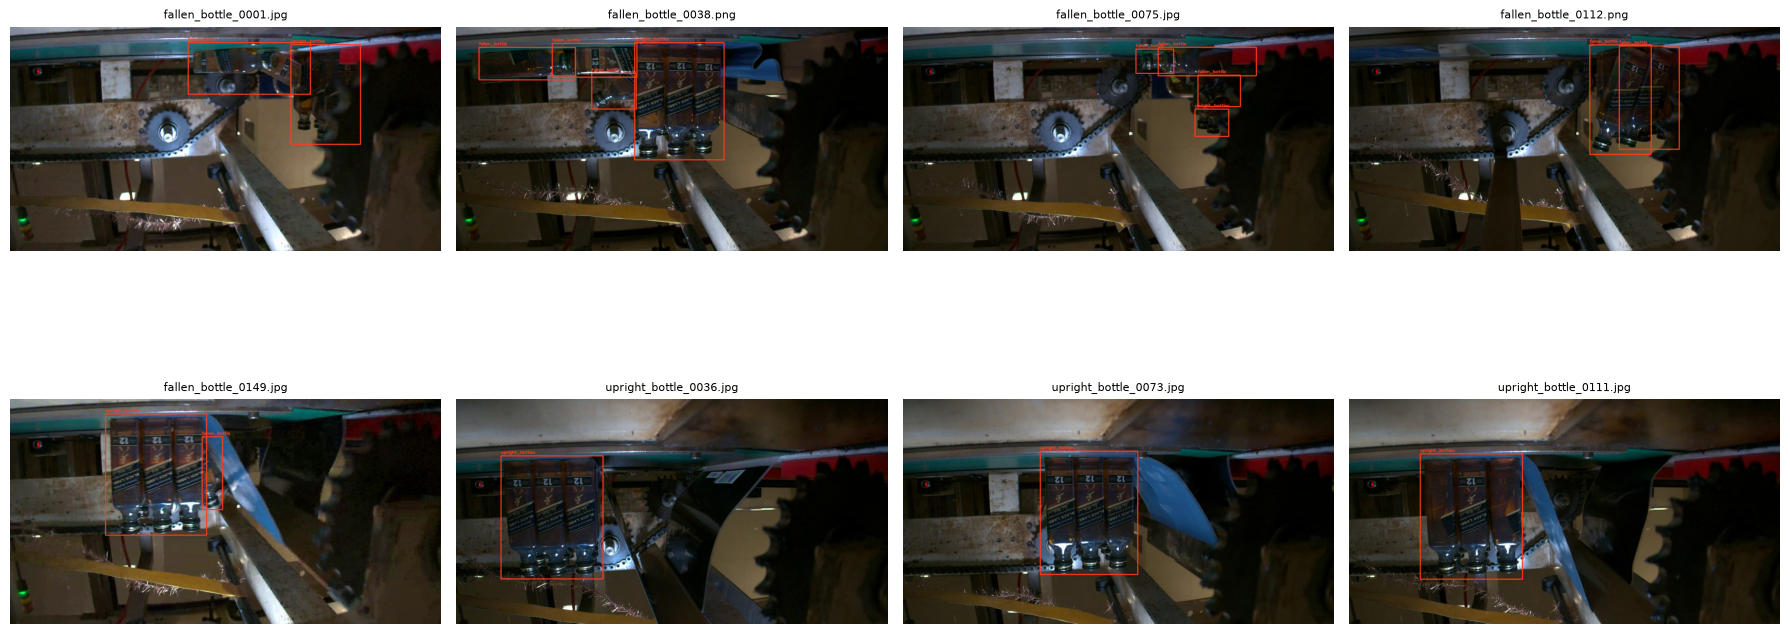

In [34]:
import cv2
import matplotlib.pyplot as plt

preview_xmls = xml_files[::max(1, len(xml_files) // 8)][:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, xml_path in zip(axes.flat, preview_xmls):
    root = ET.parse(xml_path).getroot()
    image_path = image_by_stem[xml_path.stem]
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    for obj in root.findall("object"):
        label = obj.findtext("name")
        bbox = obj.find("bndbox")
        x1 = int(float(bbox.findtext("xmin")))
        y1 = int(float(bbox.findtext("ymin")))
        x2 = int(float(bbox.findtext("xmax")))
        y2 = int(float(bbox.findtext("ymax")))
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 60, 30), 3)
        cv2.putText(image, label, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 60, 30), 2)
    ax.imshow(image)
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")

for ax in axes.flat[len(preview_xmls):]:
    ax.axis("off")
plt.tight_layout()

## 4. Configure and train YOLO through VideoModule

This is the same high-level API used by the demo notebook. The POC defaults to YOLO nano for 50 epochs. Background negatives are capped at the configured 0.5 ratio, which permits all 100 negatives for 300 labelled images.

In [35]:
from VideoModule.detection import AugmentationConfig, TrainConfig

augmentation = AugmentationConfig(
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=5.0,
    translate=0.1,
    scale=0.4,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.0,
)

config = TrainConfig(
    framework="yolo",
    # paired_dataset contains one image beside each matching Pascal VOC XML.
    # xml_dir=None uses VideoModule's recursive/adjacent-file auto-discovery.
    input_dir=str(PAIRED_DIR),
    xml_dir=None,
    output_dir=str(OUTPUT_DIR),
    model_size="n",
    epochs=50,
    batch_size=8,
    imgsz=640,
    train_split=0.70,
    val_split=0.20,
    test_split=0.10,
    seed=1337,
    augmentation=augmentation,
    negatives_dir=str(NEGATIVES_DIR),
    discover_negatives=False,
    max_negative_ratio=0.5,
)

print(config)
print(augmentation.summary())

TrainConfig(framework='yolo', input_dir='C:\\Users\\TomKitching\\Documents\\24H_INSIGHTS\\24H_Insights\\classifier\\data\\object_detection_poc_annotation\\paired_dataset', xml_dir=None, dataset_dir=None, output_dir='C:\\Users\\TomKitching\\Documents\\24H_INSIGHTS\\24H_Insights\\classifier\\data\\object_detection_poc_runs_paired', image_extensions=['.jpg', '.jpeg', '.png', '.bmp'], label_extensions=['.xml'], recursive_search=True, require_all_labels=False, train_split=0.7, val_split=0.2, test_split=0.1, seed=1337, epochs=50, batch_size=8, learning_rate=0.01, model_size='n', imgsz=640, freeze_backbone=True, augmentation=AugmentationConfig(enabled=True, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, degrees=5.0, translate=0.1, scale=0.4, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.0, sahi_amount=0.0, neg_aug_amount=0.0, sahi_slice_size=640, sahi_overlap_ratio=0.2, sahi_min_area_ratio=0.1, neg_aug_cache_dir='.cache/coco_negatives', neg_aug_max_per_download=1

In [36]:
import importlib

# Reload the implementation so notebook kernels started before a VideoModule edit
# cannot retain the old non-recursive explicit-pair discovery function.
train_pipeline_module = importlib.import_module(
    "VideoModule.detection.object_detection.training.train_pipeline"
)
train_pipeline_module = importlib.reload(train_pipeline_module)
train_pipeline = train_pipeline_module.train_pipeline

# Fail with useful path/count diagnostics before the longer staging/training run.
if config.xml_dir is None:
    preflight_pairs = train_pipeline_module.discover_image_label_pairs(
        input_dir=Path(config.input_dir),
        image_extensions=config.image_extensions,
        label_extensions=config.label_extensions,
        auto_discover_labels=True,
        recursive=config.recursive_search,
    )
else:
    preflight_pairs = train_pipeline_module._build_explicit_pairs(
        image_dir=Path(config.input_dir),
        label_dir=Path(config.xml_dir),
        image_extensions=config.image_extensions,
        label_extensions=config.label_extensions,
        recursive=config.recursive_search,
    )
preflight_valid_pairs = [(image, xml) for image, xml in preflight_pairs if xml is not None]
print(f"Training implementation: {Path(train_pipeline_module.__file__).resolve()}")
print(f"Image directory:        {Path(config.input_dir).resolve()}")
print(f"Annotation mode:        {'paired/automatic' if config.xml_dir is None else Path(config.xml_dir).resolve()}")
print(f"Images discovered:      {len(preflight_pairs)}")
print(f"Valid annotated pairs:  {len(preflight_valid_pairs)}")
print(f"Unlabelled images:       {len(preflight_pairs) - len(preflight_valid_pairs)}")
if not preflight_valid_pairs:
    raise ValueError("Discovery preflight found no valid image/XML pairs; check the paths above")

assert torch.cuda.is_available(), "CUDA became unavailable before training"
torch.cuda.set_device(0)
checkpoint = train_pipeline(config)
print(f"Best checkpoint: {checkpoint}")

2026-07-27 16:03:42,770 - INFO - Discovering images in: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_annotation\paired_dataset
2026-07-27 16:03:42,771 - INFO -   Image formats: ['.jpg', '.jpeg', '.png', '.bmp']
2026-07-27 16:03:42,772 - INFO -   Recursive: True
2026-07-27 16:03:42,772 - INFO -   Auto-discover labels: True
2026-07-27 16:03:42,778 - INFO -   Found 296 images
2026-07-27 16:03:42,780 - INFO -   Found 296 label files
2026-07-27 16:03:42,787 - INFO -   Paired: 296 images
2026-07-27 16:03:42,789 - INFO - ================================================================================
2026-07-27 16:03:42,790 - INFO - Training Configuration:
  Framework: YOLO
  Epochs: 50
  Batch size: 8
  Learning rate: 0.01
  Model: YOLOv8n
  Image size: 640
  Data split: 70%/20%/10%
  Score threshold: 0.5

Input Configuration:
  Input directory: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detecti

Training implementation: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\VideoModule\detection\object_detection\training\train_pipeline.py
Image directory:        C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_annotation\paired_dataset
Annotation mode:        paired/automatic
Images discovered:      296
Valid annotated pairs:  296
Unlabelled images:       0


2026-07-27 16:03:45,046 - INFO -   Successfully staged: 296 pairs
2026-07-27 16:03:45,047 - INFO - 
[3/7] Loading staged labels...
2026-07-27 16:03:45,048 - INFO -   Loaded 296 labels
2026-07-27 16:03:45,048 - INFO - 
[4/7] Skipping negative augmentation (disabled)
2026-07-27 16:03:45,049 - INFO - 
[5/7] Skipping SAHI slicing (disabled)
2026-07-27 16:03:45,049 - INFO - 
[5.5/7] Organizing augmented dataset...
2026-07-27 16:03:47,420 - INFO -     Original: 296 | Negatives: 0 | SAHI slices: 0
2026-07-27 16:03:47,421 - INFO -   Organized 296 images in C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\augmented_dataset
2026-07-27 16:03:47,421 - INFO - 
[6/7] Splitting augmented dataset...
2026-07-27 16:03:47,422 - INFO -   Total: 296 | Train: 207 | Val: 89
2026-07-27 16:03:47,422 - INFO - 
[7/7] Converting to YOLO format and training...
2026-07-27 16:03:48,110 - INFO - Starting VOC XML to YOLO conversion (train

Ultralytics 8.4.107  Python-3.13.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080 Laptop GPU, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\yolo_dataset\dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, m

2026-07-27 16:11:37,401 - INFO - ================================================================================
2026-07-27 16:11:37,402 - INFO - TRAINING COMPLETED
2026-07-27 16:11:37,403 - INFO - ✓ Best checkpoint saved: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt
2026-07-27 16:11:37,403 - INFO - ================================================================================
2026-07-27 16:11:37,403 - INFO - 
2026-07-27 16:11:37,404 - INFO - TRAINING COMPLETE
2026-07-27 16:11:37,404 - INFO - ================================================================================
2026-07-27 16:11:37,404 - INFO - Best checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt


Best checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt


## 5. Test the trained detector on an image

2026-07-27 16:11:37,411 - INFO - Initialized YOLODetector with model size: yolov8m
2026-07-27 16:11:37,411 - INFO -   Device: cuda
2026-07-27 16:11:37,412 - INFO - Loading YOLO checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt
2026-07-27 16:11:37,428 - INFO - ✓ Loaded checkpoint with 2 classes
2026-07-27 16:11:37,428 - INFO -   Classes: ['fallen_bottle', 'upright_bottles']


C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_annotation\images\fallen_bottle\fallen_bottle_0001.jpg
Inference device: cuda:0
{'fallen_bottle': 1, 'upright_bottles': 1}


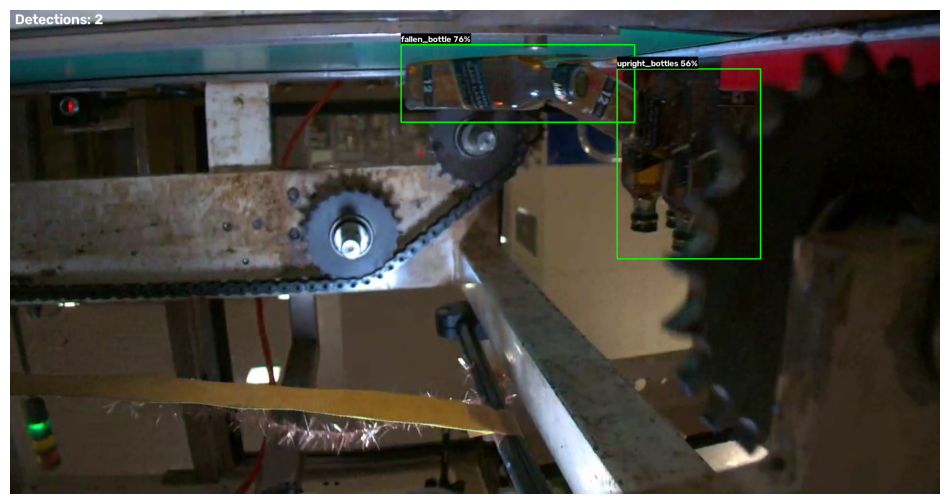

In [37]:
from VideoModule.detection import (
    get_detection_summary,
    load_yolo_model,
    run_yolo_detection,
    visualize_yolo_detections,
)

model = load_yolo_model(checkpoint, device=CUDA_DEVICE)
test_image_path = positive_images[0]
test_image = cv2.imread(str(test_image_path))
result = run_yolo_detection(model, test_image, confidence_threshold=0.25)
annotated = visualize_yolo_detections(test_image, result)

print(test_image_path)
print(f"Inference device: {result.device}")
assert str(result.device).startswith("cuda"), f"Expected CUDA inference, got {result.device}"
print(get_detection_summary(result))
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 6. Optional video inference through VideoModule

In [38]:
from VideoModule.detection import infer_video, load_detector

detector = load_detector(checkpoint, framework="yolo")
assert str(detector.device).startswith("cuda"), f"Expected CUDA detector, got {detector.device}"
print(f"Video inference device: {detector.device}")

# Set this to a classifier training clip when ready.
VIDEO_PATH = None
if VIDEO_PATH is None:
    print("Set VIDEO_PATH to run annotated video inference")
else:
    video_path = Path(VIDEO_PATH)
    annotated_path = OUTPUT_DIR / f"{video_path.stem}_detected.mp4"
    stats = infer_video(
        detector,
        video_path,
        output_path=annotated_path,
        score_threshold=0.25,
    )
    print(stats)
    print(f"Annotated video: {annotated_path}")

2026-07-27 16:11:37,849 - INFO - Initialized YOLODetector with model size: yolov8m
2026-07-27 16:11:37,850 - INFO -   Device: cuda
2026-07-27 16:11:37,850 - INFO - Loading YOLO checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt
2026-07-27 16:11:37,868 - INFO - ✓ Loaded checkpoint with 2 classes
2026-07-27 16:11:37,869 - INFO -   Classes: ['fallen_bottle', 'upright_bottles']
2026-07-27 16:11:37,869 - INFO - Loaded YOLO detector from C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt


Video inference device: cuda
Set VIDEO_PATH to run annotated video inference
